# Notebook 06 - Deep Learning Model

This notebook trains a Deep Learning model using TensorFlow and Keras for intent classification.

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

import pickle

In [3]:
intents = pd.read_csv("../dataset/intents_clean.csv")

In [4]:
intents.head()

,text,intent,response
0,catch later,goodbye,Response for goodbye.
1,hi,greeting,Response for greeting.
2,good morning,greeting,Response for greeting.
3,cost redmi note 14,price_query,Response for price_query.
4,availability galaxy s24,availability,Response for availability.


In [5]:
X = intents["text"]

y = intents["intent"]

In [6]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [7]:
y = to_categorical(y)

In [8]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(X)

In [9]:
X = tokenizer.texts_to_sequences(X)

In [10]:
print(X[:5])

[[55, 56], [36], [23, 30], [31, 7, 8, 2], [72, 9, 10]]


In [11]:
max_length = 20

X = pad_sequences(

X,

maxlen=max_length,

padding="post"

)

In [12]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

In [13]:
vocab_size = len(tokenizer.word_index)+1

print(vocab_size)

78


In [14]:
model = Sequential()

In [15]:
model.add(

Embedding(

input_dim=vocab_size,

output_dim=128,

input_length=max_length

)

)

c:\Users\jayas\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
model.add(

LSTM(64)

)

In [17]:
model.add(

Dropout(0.5)

)

In [18]:
model.add(

Dense(

64,

activation="relu"

)

)

In [19]:
model.add(

Dense(

y.shape[1],

activation="softmax"

)

)

In [20]:
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(

X_train,

y_train,

epochs=20,

batch_size=32,

validation_split=0.2

)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.0828 - loss: 2.3058 - val_accuracy: 0.1187 - val_loss: 2.3019
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0984 - loss: 2.3049 - val_accuracy: 0.1187 - val_loss: 2.2984
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1016 - loss: 2.3011 - val_accuracy: 0.0688 - val_loss: 2.2985
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1344 - loss: 2.2828 - val_accuracy: 0.2500 - val_loss: 2.1937
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2094 - loss: 1.9443 - val_accuracy: 0.1688 - val_loss: 1.7585
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1734 - loss: 1.8495 - val_accuracy: 0.1813 - val_loss: 1.8726
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2031 - loss: 1.8295 - val_accuracy: 0.2000 - val_loss: 1.8045
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2453 - loss: 1.7172 - val_accuracy: 0.3562 - v

In [23]:
loss,accuracy=model.evaluate(

X_test,

y_test

)

print("Accuracy :",accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6100 - loss: 0.9553 
Accuracy : 0.6100000143051147


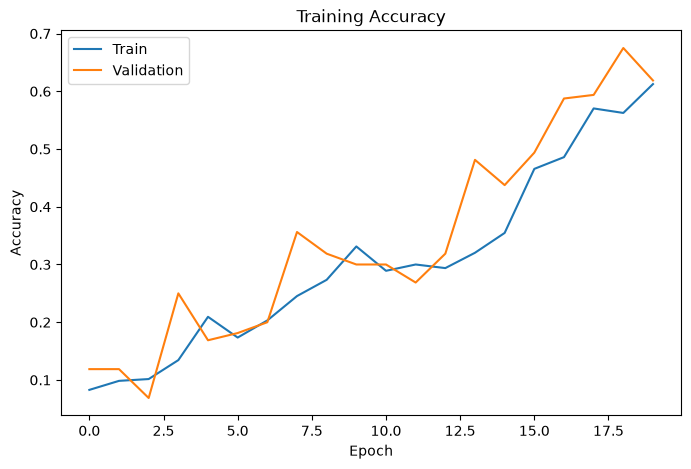

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

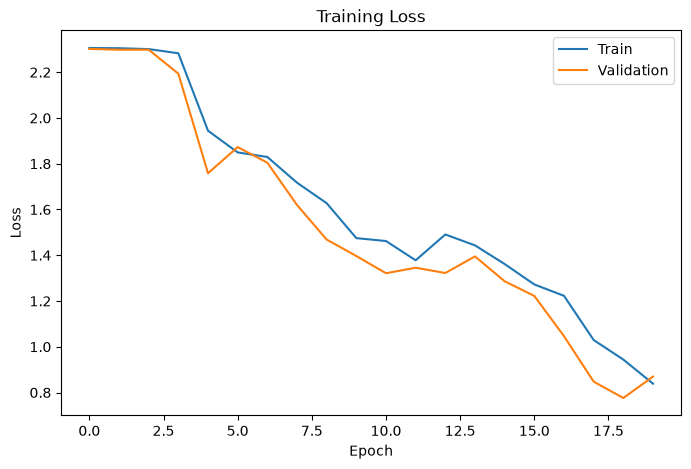

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [26]:
sentence = ["show samsung phones"]

In [27]:
sequence = tokenizer.texts_to_sequences(sentence)

sequence = pad_sequences(

sequence,

maxlen=max_length,

padding="post"

)

In [28]:
prediction = model.predict(sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step


In [29]:
predicted = np.argmax(prediction)

In [30]:
print(

encoder.inverse_transform(

[predicted]

)

)

['phone_search']


In [31]:
sentence = ["show samsung phones"]

seq = tokenizer.texts_to_sequences(sentence)

seq = pad_sequences(
    seq,
    maxlen=50,
    padding='post'
)

prediction = model.predict(seq)

intent_id = prediction.argmax()

intent = encoder.inverse_transform([intent_id])

print("User:", sentence[0])
print("Predicted Intent:", intent[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
User: show samsung phones
Predicted Intent: phone_search


In [32]:
intents['intent'].value_counts()

intent
accessory_search    114
price_query         107
payment             106
comparison          101
goodbye             100
greeting             99
recommendation       96
thanks               95
phone_search         94
availability         88
Name: count, dtype: int64

In [33]:
model.save(

"../models/lstm_intent_model.keras"

)

In [34]:
pickle.dump(

tokenizer,

open("../models/tokenizer.pkl","wb")

)

In [35]:
pickle.dump(

encoder,

open("../models/dl_label_encoder.pkl","wb")

)

In [36]:
print("Deep Learning Model Saved Successfully!")

Deep Learning Model Saved Successfully!
